# Penn World Table

National accounts built for comparison, from Feenstra, Inklaar and Timmer at Groningen. The World
Bank panel carries output and population. This carries the capital stock, employment and
productivity that a growth model needs, and it is where the frontier in this project's forecast
comes from.

## Provenance

These are the fields of the `PWT` declaration in `climate_risk/data/pwt.py`. It is a `ManualSource`:
the workbook is downloaded from the Groningen page by hand and placed in the cache.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.pwt import PWT

declared = {"publisher": "Groningen Growth and Development Centre"} | dataclasses.asdict(PWT)
rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | Groningen Growth and Development Centre |
| filename | pwt100.xlsx |
| homepage | https://www.rug.nl/ggdc/productivity/pwt/ |
| license | Creative Commons Attribution 4.0 |
| citation | Feenstra, Robert C., Robert Inklaar and Marcel P. Timmer (2015), 'The Next Generation of the Penn World Table', American Economic Review 105(10), 3150-3182 |
| retrieved | 2026-08-13 |

## Loading it

`load_pwt_data` reads the workbook you placed in the cache directory and caches the panel beside it.
Until the file is there it raises with the license and the exact path it wants. The cache directory
is your choice, and this page uses one named `data` in the working directory.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from climate_risk.data.pwt import PWT_COLUMNS, load_pwt_data
from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

pwt = load_pwt_data(cache_dir)

## What you get

A polars frame, one row per country and year, with seven series under readable names rather than
the workbook's codes.

In [4]:
pwt.head()

country_code,year,pwt_real_gdp,capital,employment,pwt_population,labour_share,depreciation,tfp_relative_to_usa
str,i64,f64,f64,f64,f64,f64,f64,f64
"""ABW""",1950,null,null,null,null,null,null,null
"""ABW""",1951,null,null,null,null,null,null,null
"""ABW""",1952,null,null,null,null,null,null,null
"""ABW""",1953,null,null,null,null,null,null,null
"""ABW""",1954,null,null,null,null,null,null,null


## Units

| Column | Unit |
|---|---|
| `country_code` | ISO 3166-1 alpha-3 country code |
| `year` | calendar year |
| `pwt_real_gdp` | millions of 2017 US dollars, national prices |
| `capital` | index of capital services, 2017 = 1 |
| `employment` | millions of people engaged |
| `pwt_population` | millions of people |
| `labour_share` | share of income, between 0 and 1 |
| `depreciation` | share of the capital stock per year |
| `tfp_relative_to_usa` | index, United States = 1 |

The distinction that matters is which comparison each column supports. The `na` family, which is
`pwt_real_gdp`, `capital` and `pwt_population`, is built to be compared over time within one
country. `tfp_relative_to_usa` comes from `ctfp`, a level at current purchasing power parities with
the United States at 1, and it is the only column here that compares countries to each other.

In [5]:
pl.DataFrame({"workbook code": list(PWT_COLUMNS), "column": list(PWT_COLUMNS.values())})

workbook code,column
str,str
"""rgdpna""","""pwt_real_gdp"""
"""rkna""","""capital"""
"""emp""","""employment"""
"""pop""","""pwt_population"""
"""labsh""","""labour_share"""
"""delta""","""depreciation"""
"""ctfp""","""tfp_relative_to_usa"""


## Coverage

The table runs to 2019 and stops. Half the productivity column is empty, and the capital stock is
missing for nearly half the panel, so a model reading both is estimated on far less than the row
count suggests.

In [6]:
series = [name for name in pwt.columns if name not in ("country_code", "year")]

pl.DataFrame(
    {
        "column": series,
        "reported": [pwt[name].is_not_null().sum() for name in series],
        "share": [pwt[name].is_not_null().sum() / len(pwt) for name in series],
    }
)

column,reported,share
str,i64,f64
"""pwt_real_gdp""",10399,0.811788
"""capital""",7095,0.553864
"""employment""",9529,0.743872
"""pwt_population""",10399,0.811788
"""labour_share""",7970,0.62217
"""depreciation""",10314,0.805152
"""tfp_relative_to_usa""",6412,0.500546


In [7]:
pl.DataFrame(
    {
        "rows": [len(pwt)],
        "countries": [pwt["country_code"].n_unique()],
        "first": [pwt["year"].min()],
        "last": [pwt["year"].max()],
    }
)

rows,countries,first,last
i64,i64,i64,i64
12810,183,1950,2019


## A plot

Productivity against the United States for three Southeast Asian economies, which is the comparison
`tfp_relative_to_usa` is built to support. The gap to the frontier and the slow rate at which it
closes is what the forecast in this project turns into long-run growth.

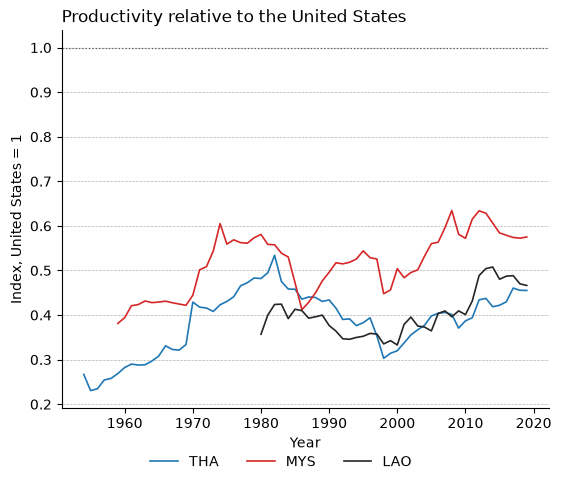

In [8]:
NEIGHBOURS = ("THA", "MYS", "LAO")
COLORS = (PALETTE["primary"], PALETTE["secondary"], PALETTE["observed"])

figure, axis = plt.subplots(figsize=(5.5, 4.5))
for iso, color in zip(NEIGHBOURS, COLORS, strict=True):
    block = pwt.filter((pl.col("country_code") == iso) & pl.col("tfp_relative_to_usa").is_not_null()).sort("year")
    axis.plot(block["year"], block["tfp_relative_to_usa"], color=color, lw=1.2, label=iso)

axis.axhline(1.0, color=PALETTE["divider"], ls=":", lw=0.9)
axis.set_title("Productivity relative to the United States", loc="left")
axis.set_xlabel("Year")
axis.set_ylabel("Index, United States = 1")

handles, labels = axis.get_legend_handles_labels()
figure.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=3, frameon=False)

plt.show()

## Gotchas

*Most columns cannot be compared across countries.* `pwt_real_gdp` and `capital` are national-price
series, so their levels say nothing about one country against another. Only `tfp_relative_to_usa`
is built for that, and it is the emptiest column in the table.

*Two of this project's neighbours have no productivity at all.* Vietnam and Cambodia carry no
`tfp_relative_to_usa` in any year. A frontier-gap model built over the region has to choose
countries by what the table reports rather than by what it would like to include.

*`capital` is an index, not a stock.* It is 1 in 2017 by construction, so its level carries no
information and only its movement does. The same is true of its ratio to output, which is why the
paper notebook centers `log(capital / pwt_real_gdp)` on its own mean.

*The panel ends in 2019.* This is version 10.0 and it stops before the pandemic. Anything joining it
to a series that runs to the present gets nulls from 2020 on, not an error.

*`employment` and `pwt_population` are in millions.* The World Bank panel reports population in
people. Joining the two and differencing them without converting is off by a factor of a million.